In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import pickle

from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

In [2]:
# -----------------------------------
# 1. 데이터 불러오기
# -----------------------------------
df = pd.read_csv("../datasets/ecommerce_company_client_churn_data.csv")

# 데이터 확인
print("데이터 크기:", df.shape)
print(df.head())

데이터 크기: (1000, 51)
                            user_id                          platform  \
0  a571a717903d731460c3f8b012897aa6  4128403e5dad4f40eb5c79a92a5719c9   
1  c681dc7c20837e3ea7a0c0531e3d4eb6  4128403e5dad4f40eb5c79a92a5719c9   
2  9d8cbbb590831fb2e61b4dbefe4543d4  c44577a5b4c0036fe1ec82c04bfa87c6   
3  3ce08777163438749f3110c10b72d6be  4128403e5dad4f40eb5c79a92a5719c9   
4  36989756b0656e71577f284a7e7af62a  4128403e5dad4f40eb5c79a92a5719c9   

                     market_country   user_creation_datetime  \
0  6b681da4aa6e2f33a5f06ff660ba0e9e  2019-06-10 17:10:15 UTC   
1  64f6711e77d2ec8af8ac3292c66d2875  2019-03-12 09:52:44 UTC   
2  9a6e56e83f8d0f692203f7b4850f86ff  2019-08-30 14:04:15 UTC   
3  c097bb1538327aaf74797d23f6fcef83  2020-08-16 20:56:37 UTC   
4  c097bb1538327aaf74797d23f6fcef83  2020-04-24 08:25:17 UTC   

     confirmation_datetime  first_purchase_datetime   last_purchase_datetime  \
0  2019-06-10 17:10:15 UTC  2019-08-19 16:01:43 UTC  2021-03-06 18:21:17 UTC 

In [3]:
# -----------------------------------
# 2. 타깃(status) 생성
# ok=0, churned=1
# -----------------------------------
df["status"] = df["status"].map({"ok": 0, "churned": 1})

# -----------------------------------
# 3. 날짜형 컬럼 datetime 변환
# -----------------------------------
datetime_cols = [
    "user_creation_datetime",
    "confirmation_datetime",
    "first_purchase_datetime",
    "last_purchase_datetime",
    "first_integration_datetime"
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# -----------------------------------
# 4. 날짜 파생 변수 생성
# -----------------------------------
df["days_to_confirm"] = (df["confirmation_datetime"] - df["user_creation_datetime"]).dt.days
df["days_to_first_purchase"] = (df["first_purchase_datetime"] - df["user_creation_datetime"]).dt.days
df["days_to_last_purchase"] = (df["last_purchase_datetime"] - df["user_creation_datetime"]).dt.days
df["days_first_to_last_purchase"] = (df["last_purchase_datetime"] - df["first_purchase_datetime"]).dt.days
df["days_to_first_integration"] = (df["first_integration_datetime"] - df["user_creation_datetime"]).dt.days

# datetime 존재 여부도 정보가 될 수 있으므로 flag 추가
df["has_confirmation"] = df["confirmation_datetime"].notna().astype(int)
df["has_integration"] = df["first_integration_datetime"].notna().astype(int)

# -----------------------------------
# 5. 원본 datetime 컬럼 제거
# -----------------------------------
df = df.drop(columns=datetime_cols)

# -----------------------------------
# 6. 입력(X), 타깃(y) 분리
# user_id: 식별자 제거
# churn_factor: 누수 가능성이 높아 제거
# -----------------------------------
X = df.drop(columns=["user_id", "churn_factor", "status"])
y = df["status"]

# -----------------------------------
# 7. 범주형 변수 인코딩
# platform, market_country, last_segment_recorded
# -----------------------------------
categorical_cols = ["platform", "market_country", "last_segment_recorded"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\n전처리 후 입력 데이터 컬럼:")
print(X.columns)

# -----------------------------------
# 8. 결측치 처리
# 수치형은 중앙값으로 채움
# -----------------------------------
X = X.fillna(X.median(numeric_only=True))

# -----------------------------------
# 9. train / val / test 분리
# stratify=y 로 클래스 비율 유지
# -----------------------------------

# 1차 분할: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: temp 30%를 val 15%, test 15%로 반반 분할
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

total = len(X)

print("\n" + "="*50)
print("데이터 분할 결과")
print("="*50)
print(f"전체 데이터 수      : {total}")
print(f"훈련 데이터 (train): X={X_train.shape}, y={y_train.shape}, 비율={len(X_train)/total:.1%}")
print(f"검증 데이터 (val)  : X={X_val.shape}, y={y_val.shape}, 비율={len(X_val)/total:.1%}")
print(f"테스트 데이터 (test): X={X_test.shape}, y={y_test.shape}, 비율={len(X_test)/total:.1%}")

# -----------------------------------
# 10. Logistic Regression용 스케일링
# 트리 계열은 스케일링 없이도 됨
# -----------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


전처리 후 입력 데이터 컬럼:
Index(['longevity', 'total_sales', 'avg_sales_per_day', 'min_days_btwn_sales',
       'frst_quartile_days_btwn_sales', 'avg_days_btwn_sales',
       'median_days_btwn_sales', 'thrd_quartile_days_btwn_sales',
       'max_days_btwn_sales', 'min_days_btwn_sale_date',
       'fst_quartile_days_btwn_sale_date', 'avg_days_btwn_sale_date',
       'median_days_btwn_sale_date', 'thrd_quartile_days_btwn_sale_date',
       'frequency', 'recency', 'month_label_count', 'quarter_label_count',
       'year_label_count', 'previous_year_label_count', 'historic_label_count',
       'month_revenue_eur', 'quarter_revenue_eur', 'year_revenue_eur',
       'previous_year_revenue_eur', 'historic_revenue_eur',
       'month_average_order_value', 'quarter_aov', 'year_aov',
       'year_plat_cntry_aov', 'previous_year_aov',
       'previous_year_plat_cntry_aov', 'historic_aov', 'csat',
       'cs_tickets_good', 'cs_tickets_offered', 'cs_tickets_unoffered',
       'cs_tickets_bad', 'customer_fee

Age: 나이  
Gender: 성별  
Annual_Income: 연소득  
Spending_Score: 소비 성향 점수  
Membership_Years: 멤버십 유지 기간  
Online_Purchases: 온라인 구매 횟수  
Discount_Usage: 할인 사용 정도  
Churn: 이탈 여부  
  
  전처리가 필요한 이유
1. Customer_ID는 식별자이므로 제거

Customer_ID는 고객을 구분하기 위한 번호일 뿐, 고객의 이탈 여부를 설명하는 실제 행동 특성은 아닙니다.
이런 식별자 컬럼을 그대로 모델에 넣으면, 모델이 의미 없는 번호 패턴을 학습할 수 있으므로 제거하는 것이 적절합니다.

2. Gender는 범주형 변수이므로 숫자형으로 변환 필요

Gender는 문자열 범주형 데이터이기 때문에, 대부분의 머신러닝 모델이 그대로 처리할 수 없습니다.
따라서 원-핫 인코딩이나 더미 변수 변환을 통해 숫자형 데이터로 바꿔야 합니다.

3. Churn은 타깃 변수이므로 입력과 분리

Churn은 예측하려는 정답값이므로 입력 변수(X)와 분리해야 합니다.
즉 나머지 컬럼들로 Churn을 맞히는 구조로 데이터를 구성해야 합니다.

4. 클래스가 약간 불균형하므로 평가 지표를 주의해야 함

이 데이터는

Churn = 0: 1379개
Churn = 1: 621개

로, 완전히 균형 잡힌 데이터는 아닙니다.
이 경우 accuracy만 보면 모델이 다수 클래스(0)만 많이 예측해도 성능이 좋아 보일 수 있으므로, precision, recall, f1-score도 함께 확인하는 것이 중요합니다.


5. 이 데이터는 수치형 변수와 Churn 사이의 관계가 아주 뚜렷한 선형 구조라고 보기 어렵습니다.
즉 로지스틱 회귀 같은 단순 선형 모델 하나로는 분리가 잘 안 될 수 있고,
비선형 관계와 변수 간 상호작용을 잘 잡는 트리 기반 모델(Random Forest, XGBoost, CatBoost 등)이 더 좋은 성능을 낼 가능성이 있어 트리 기반 모델로 학습 후 저장할 예정입니다.

In [4]:
# -----------------------------------
# 6. 모델 생성
# -----------------------------------
log_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)

tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini",
    random_state=42,
    class_weight="balanced",
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42,
    class_weight="balanced",
)

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model_name, y_true, y_pred, split_name):
    print("\n" + "="*60)
    print(f"{model_name} | {split_name} 결과")
    print("="*60)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

In [6]:
# -----------------------------------
# 7. Logistic Regression 학습 및 평가
# -----------------------------------
log_model.fit(X_train_scaled, y_train)

# 예측
y_pred_log_train = log_model.predict(X_train_scaled)
y_pred_log_val = log_model.predict(X_val_scaled)
y_pred_log_test = log_model.predict(X_test_scaled)

# 평가
evaluate_model("Logistic Regression", y_train, y_pred_log_train, "Train")
evaluate_model("Logistic Regression", y_val, y_pred_log_val, "Validation")
evaluate_model("Logistic Regression", y_test, y_pred_log_test, "Test")


Logistic Regression | Train 결과
Accuracy: 0.9814285714285714
Confusion Matrix:
 [[354   2]
 [ 11 333]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       356
           1       0.99      0.97      0.98       344

    accuracy                           0.98       700
   macro avg       0.98      0.98      0.98       700
weighted avg       0.98      0.98      0.98       700


Logistic Regression | Validation 결과
Accuracy: 0.96
Confusion Matrix:
 [[74  2]
 [ 4 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        76
           1       0.97      0.95      0.96        74

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


Logistic Regression | Test 결과
Accuracy: 0.9466666666666667
Confusion Matrix:
 [[75  1]
 [ 7 67]]
Classif

In [7]:
# -----------------------------------
# 8. Decision Tree 학습 및 평가
# -----------------------------------
tree_model.fit(X_train, y_train)

# 예측
y_pred_tree_train = tree_model.predict(X_train)
y_pred_tree_val = tree_model.predict(X_val)
y_pred_tree_test = tree_model.predict(X_test)

# 평가
evaluate_model("Decision Tree", y_train, y_pred_tree_train, "Train")
evaluate_model("Decision Tree", y_val, y_pred_tree_val, "Validation")
evaluate_model("Decision Tree", y_test, y_pred_tree_test, "Test")


Decision Tree | Train 결과
Accuracy: 0.9814285714285714
Confusion Matrix:
 [[354   2]
 [ 11 333]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       356
           1       0.99      0.97      0.98       344

    accuracy                           0.98       700
   macro avg       0.98      0.98      0.98       700
weighted avg       0.98      0.98      0.98       700


Decision Tree | Validation 결과
Accuracy: 0.9533333333333334
Confusion Matrix:
 [[73  3]
 [ 4 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95        76
           1       0.96      0.95      0.95        74

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


Decision Tree | Test 결과
Accuracy: 0.9533333333333334
Confusion Matrix:
 [[72  4]
 [ 3 71]]
Classificat

In [8]:
# -----------------------------------
# 9. Random Forest 학습 및 평가
# -----------------------------------
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_val = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

# 평가
evaluate_model("Random Forest", y_train, y_pred_rf_train, "Train")
evaluate_model("Random Forest", y_val, y_pred_rf_val, "Validation")
evaluate_model("Random Forest", y_test, y_pred_rf_test, "Test")


Random Forest | Train 결과
Accuracy: 0.9257142857142857
Confusion Matrix:
 [[338  18]
 [ 34 310]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       356
           1       0.95      0.90      0.92       344

    accuracy                           0.93       700
   macro avg       0.93      0.93      0.93       700
weighted avg       0.93      0.93      0.93       700


Random Forest | Validation 결과
Accuracy: 0.8733333333333333
Confusion Matrix:
 [[73  3]
 [16 58]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.88        76
           1       0.95      0.78      0.86        74

    accuracy                           0.87       150
   macro avg       0.89      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150


Random Forest | Test 결과
Accuracy: 0.92
Confusion Matrix:
 [[73  3]
 [ 9 65]]
Classification Report:
  

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Logistic Regression", "Logistic Regression",
              "Decision Tree", "Decision Tree", "Decision Tree",
              "Random Forest", "Random Forest", "Random Forest"],
    "Split": ["Train", "Validation", "Test",
              "Train", "Validation", "Test",
              "Train", "Validation", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_pred_log_train),
        accuracy_score(y_val, y_pred_log_val),
        accuracy_score(y_test, y_pred_log_test),

        accuracy_score(y_train, y_pred_tree_train),
        accuracy_score(y_val, y_pred_tree_val),
        accuracy_score(y_test, y_pred_tree_test),

        accuracy_score(y_train, y_pred_rf_train),
        accuracy_score(y_val, y_pred_rf_val),
        accuracy_score(y_test, y_pred_rf_test),
    ]
})

print(results)

                 Model       Split  Accuracy
0  Logistic Regression       Train  0.981429
1  Logistic Regression  Validation  0.960000
2  Logistic Regression        Test  0.946667
3        Decision Tree       Train  0.981429
4        Decision Tree  Validation  0.953333
5        Decision Tree        Test  0.953333
6        Random Forest       Train  0.925714
7        Random Forest  Validation  0.873333
8        Random Forest        Test  0.920000


In [10]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("dt", tree_model),
        ("rf", rf_model)
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)
y_prob_vote = voting_model.predict_proba(X_test)[:, 1]
y_pred_vote = (y_prob_vote >= 0.7).astype(int)

c:\Users\Playdata\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print("\n" + "="*50)
print("Voting model 결과")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))
print("Classification Report:\n", classification_report(y_test, y_pred_vote))


Voting model 결과
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[75  1]
 [ 4 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        76
           1       0.99      0.95      0.97        74

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



비선형 표로 되어있는 자료는 XGboost로 학습시키는 것이 좋다고 판단되어 Xg_boost로 학습진행했습니다

In [12]:
# -----------------------------------
# 1. XGBoost 모델 생성
# -----------------------------------
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    random_state=42,
    eval_metric="logloss"
)


In [13]:
# -----------------------------------
# 2. XGBoost 학습
# -----------------------------------
xgb_model.fit(X_train, y_train)

# -----------------------------------
# 3. XGBoost 기본 예측 (기본 threshold=0.5 느낌)
# -----------------------------------
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_val = xgb_model.predict(X_val)

# -----------------------------------
# 4. XGBoost 기본 평가
# -----------------------------------
evaluate_model("XGBoost", y_train, y_pred_xgb_train, "Train")
evaluate_model("XGBoost", y_val, y_pred_xgb_val, "Validation (default threshold)")

# -----------------------------------
# 5. Validation에서 threshold 탐색
# -----------------------------------
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

for th in [0.3, 0.4, 0.5, 0.6]:
    y_val_pred_xgb = (y_val_prob_xgb >= th).astype(int)
    print(f"\nthreshold={th}")
    print(classification_report(y_val, y_val_pred_xgb, zero_division=0))

# -----------------------------------
# 6. 원하는 threshold를 직접 선택
# -----------------------------------
best_threshold = 0.285

# validation에서 선택한 threshold 적용
y_val_pred_xgb_best = (y_val_prob_xgb >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"XGBoost | Validation 결과 (threshold={best_threshold})")
print("="*60)
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb_best))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_xgb_best))
print("Classification Report:\n", classification_report(y_val, y_val_pred_xgb_best, zero_division=0))

# -----------------------------------
# 7. 이제 test에 최종 적용
# -----------------------------------
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_test = (y_test_prob_xgb >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"XGBoost | Test 결과 (threshold={best_threshold})")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_test))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_test, zero_division=0))


XGBoost | Train 결과
Accuracy: 1.0
Confusion Matrix:
 [[356   0]
 [  0 344]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       1.00      1.00      1.00       344

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700


XGBoost | Validation (default threshold) 결과
Accuracy: 0.9533333333333334
Confusion Matrix:
 [[75  1]
 [ 6 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96        76
           1       0.99      0.92      0.95        74

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150


threshold=0.3
              precision    recall  f1-score   support

           0       0.97      0.95      0

In [14]:
# -----------------------------------
# 5. CatBoost 모델 생성
# verbose=0 으로 학습 로그 출력 억제
# -----------------------------------
cat_model = CatBoostClassifier(
    iterations=250,
    depth=4,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=0
)

In [15]:
# -----------------------------------
# 6. CatBoost 학습
# -----------------------------------
cat_model.fit(X_train, y_train)

# -----------------------------------
# 7. CatBoost 예측
# -----------------------------------
y_pred_cat_train = cat_model.predict(X_train)
y_pred_cat_val = cat_model.predict(X_val)
y_pred_cat_test = cat_model.predict(X_test)

# predict 결과를 shape 맞게 1차원으로 정리
y_pred_cat_train = pd.Series(y_pred_cat_train.ravel())
y_pred_cat_val = pd.Series(y_pred_cat_val.ravel())
y_pred_cat_test = pd.Series(y_pred_cat_test.ravel())

# -----------------------------------
# 8. CatBoost 평가
# -----------------------------------
evaluate_model("CatBoost", y_train, y_pred_cat_train, "Train")
evaluate_model("CatBoost", y_val, y_pred_cat_val, "Validation")
evaluate_model("CatBoost", y_test, y_pred_cat_test, "Test")


CatBoost | Train 결과
Accuracy: 1.0
Confusion Matrix:
 [[356   0]
 [  0 344]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       1.00      1.00      1.00       344

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700


CatBoost | Validation 결과
Accuracy: 0.96
Confusion Matrix:
 [[74  2]
 [ 4 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        76
           1       0.97      0.95      0.96        74

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


CatBoost | Test 결과
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[74  2]
 [ 3 71]]
Classification Report:
               precision    reca


XGBoost Feature Importance (Top 15)
                              Feature  Importance
11            avg_days_btwn_sale_date    0.149797
15                            recency    0.127033
14                          frequency    0.101141
43        days_first_to_last_purchase    0.061615
13  thrd_quartile_days_btwn_sale_date    0.048202
5                 avg_days_btwn_sales    0.046384
7       thrd_quartile_days_btwn_sales    0.042845
29                year_plat_cntry_aov    0.042145
2                   avg_sales_per_day    0.028071
17                quarter_label_count    0.027230
0                           longevity    0.025050
1                         total_sales    0.022410
36               cs_tickets_unoffered    0.018409
8                 max_days_btwn_sales    0.016733
42              days_to_last_purchase    0.016564


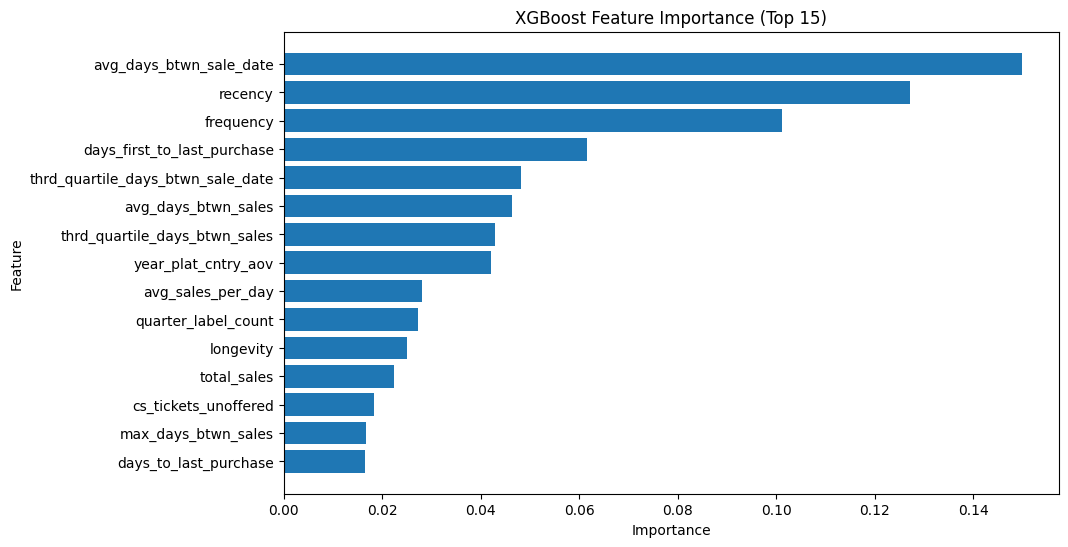


CatBoost Feature Importance (Top 15)
                              Feature  Importance
15                            recency   52.215156
14                          frequency   12.005386
11            avg_days_btwn_sale_date    9.437880
5                 avg_days_btwn_sales    6.898662
13  thrd_quartile_days_btwn_sale_date    2.617064
8                 max_days_btwn_sales    2.191641
2                   avg_sales_per_day    1.882488
12         median_days_btwn_sale_date    1.472392
43        days_first_to_last_purchase    1.467673
10   fst_quartile_days_btwn_sale_date    1.170763
7       thrd_quartile_days_btwn_sales    1.075608
0                           longevity    0.876563
18                   year_label_count    0.586592
31       previous_year_plat_cntry_aov    0.573682
6              median_days_btwn_sales    0.521985


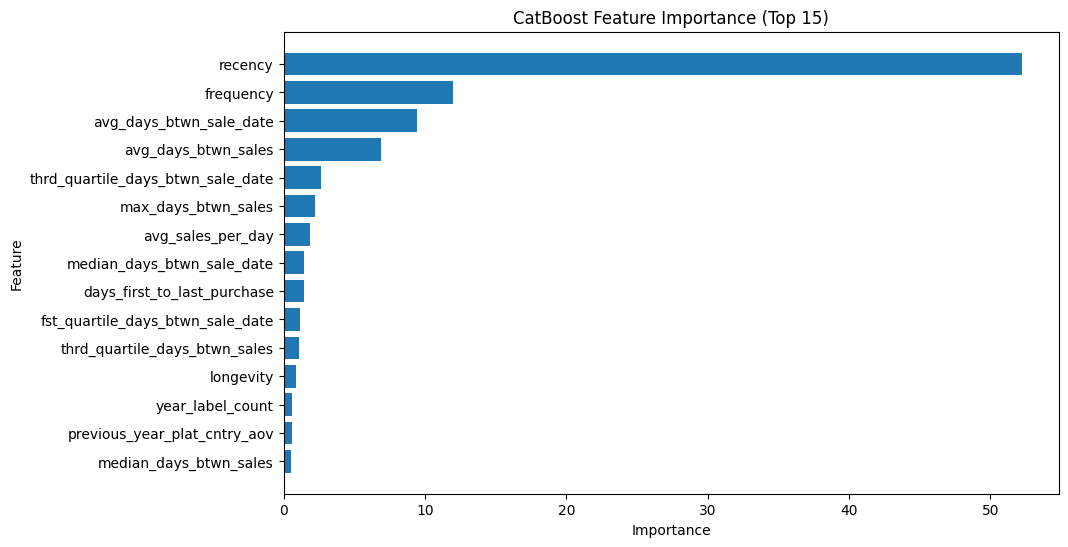

In [16]:
# -----------------------------------
# 3. XGBoost Feature Importance
# -----------------------------------
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nXGBoost Feature Importance (Top 15)")
print(xgb_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance["Feature"].head(15)[::-1], xgb_importance["Importance"].head(15)[::-1])
plt.title("XGBoost Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# -----------------------------------
# 4. CatBoost Feature Importance
# -----------------------------------
cat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print("\nCatBoost Feature Importance (Top 15)")
print(cat_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(cat_importance["Feature"].head(15)[::-1], cat_importance["Importance"].head(15)[::-1])
plt.title("CatBoost Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

현재까지 돌려본 결과 XGboost가 제일 상태가 좋은 것을 알 수 있다.  
XGBoost는 결정트리를 여러 개 이어서 점점 정답에 가깝게 만드는 머신러닝 모델이고, 비선형 방식을 잘 잡는다.

In [20]:
# 저장
with open("../artifacts/xg_model.pkl2", "wb") as f:
    pickle.dump(xgb_model, f)

In [21]:
# 불러오기
with open("../artifacts/xg_model.pkl2", "rb") as f:
    loaded_model = pickle.load(f)

In [21]:
# -----------------------------------
# 1. 이탈 확률 계산
# -----------------------------------
best_threshold = 0.35  # 사용 중인 threshold에 맞게 수정

result = X_test.copy()
result["true_label"] = y_test.values if hasattr(y_test, "values") else y_test
result["churn_probability"] = xgb_model.predict_proba(X_test)[:, 1]
result["pred_label"] = (result["churn_probability"] >= best_threshold).astype(int)

# -----------------------------------
# 2. 고위험군 / 저위험군 나누기
# 상위 20%를 고위험군, 하위 20%를 저위험군으로 설정
# -----------------------------------
high_threshold = result["churn_probability"].quantile(0.8)
low_threshold = result["churn_probability"].quantile(0.2)

high_risk = result[result["churn_probability"] >= high_threshold].copy()
low_risk = result[result["churn_probability"] <= low_threshold].copy()

print("고위험군 수:", len(high_risk))
print("저위험군 수:", len(low_risk))

# -----------------------------------
# 3. 수치형 변수 차이 비교
# -----------------------------------
numeric_cols = result.select_dtypes(include=[np.number]).columns.tolist()

# 예측/정답 관련 컬럼은 제외
exclude_cols = ["true_label", "pred_label", "churn_probability"]
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

comparison = pd.DataFrame({
    "high_risk_mean": high_risk[numeric_cols].mean(),
    "low_risk_mean": low_risk[numeric_cols].mean()
})

comparison["difference"] = comparison["high_risk_mean"] - comparison["low_risk_mean"]
comparison["abs_difference"] = comparison["difference"].abs()
comparison = comparison.sort_values("abs_difference", ascending=False)

print("\n고위험군 vs 저위험군 평균 비교")
print(comparison.head(10))

# -----------------------------------
# 4. 자동 문장 생성
# difference가 큰 상위 변수들만 설명
# -----------------------------------
top_features = comparison.head(5)

sentences = []
sentences.append("모델 예측 결과를 바탕으로 이탈 위험이 높은 고객군과 낮은 고객군을 비교한 결과, 다음과 같은 특징이 관찰되었습니다.")

for feature, row in top_features.iterrows():
    high_val = row["high_risk_mean"]
    low_val = row["low_risk_mean"]
    diff = row["difference"]

    if diff > 0:
        sentence = (
            f"- 고위험 고객군은 `{feature}` 값이 평균적으로 더 높았습니다 "
            f"(고위험군: {high_val:.2f}, 저위험군: {low_val:.2f})."
        )
    else:
        sentence = (
            f"- 고위험 고객군은 `{feature}` 값이 평균적으로 더 낮았습니다 "
            f"(고위험군: {high_val:.2f}, 저위험군: {low_val:.2f})."
        )

    sentences.append(sentence)

# -----------------------------------
# 5. 종합 문장 출력
# -----------------------------------
print("\n" + "="*60)
print("이탈 위험 고객 특성 자동 요약")
print("="*60)
for s in sentences:
    print(s)

고위험군 수: 30
저위험군 수: 30

고위험군 vs 저위험군 평균 비교
                                   high_risk_mean  low_risk_mean  difference  \
days_to_last_purchase                  214.333333     873.800000 -659.466667   
days_first_to_last_purchase            176.566667     744.300000 -567.733333   
recency                                692.766667     130.866667  561.900000   
max_days_btwn_sales                     67.200000     446.866667 -379.666667   
thrd_quartile_days_btwn_sale_date       20.366667     250.033333 -229.666667   
avg_days_btwn_sale_date                 18.400000     186.866667 -168.466667   
frequency                               18.354260     185.675770 -167.321510   
thrd_quartile_days_btwn_sales           13.966667     150.566667 -136.600000   
median_days_btwn_sale_date              12.300000     142.200000 -129.900000   
avg_days_btwn_sales                     11.600000     126.133333 -114.533333   

                                   abs_difference  
days_to_last_purchase    